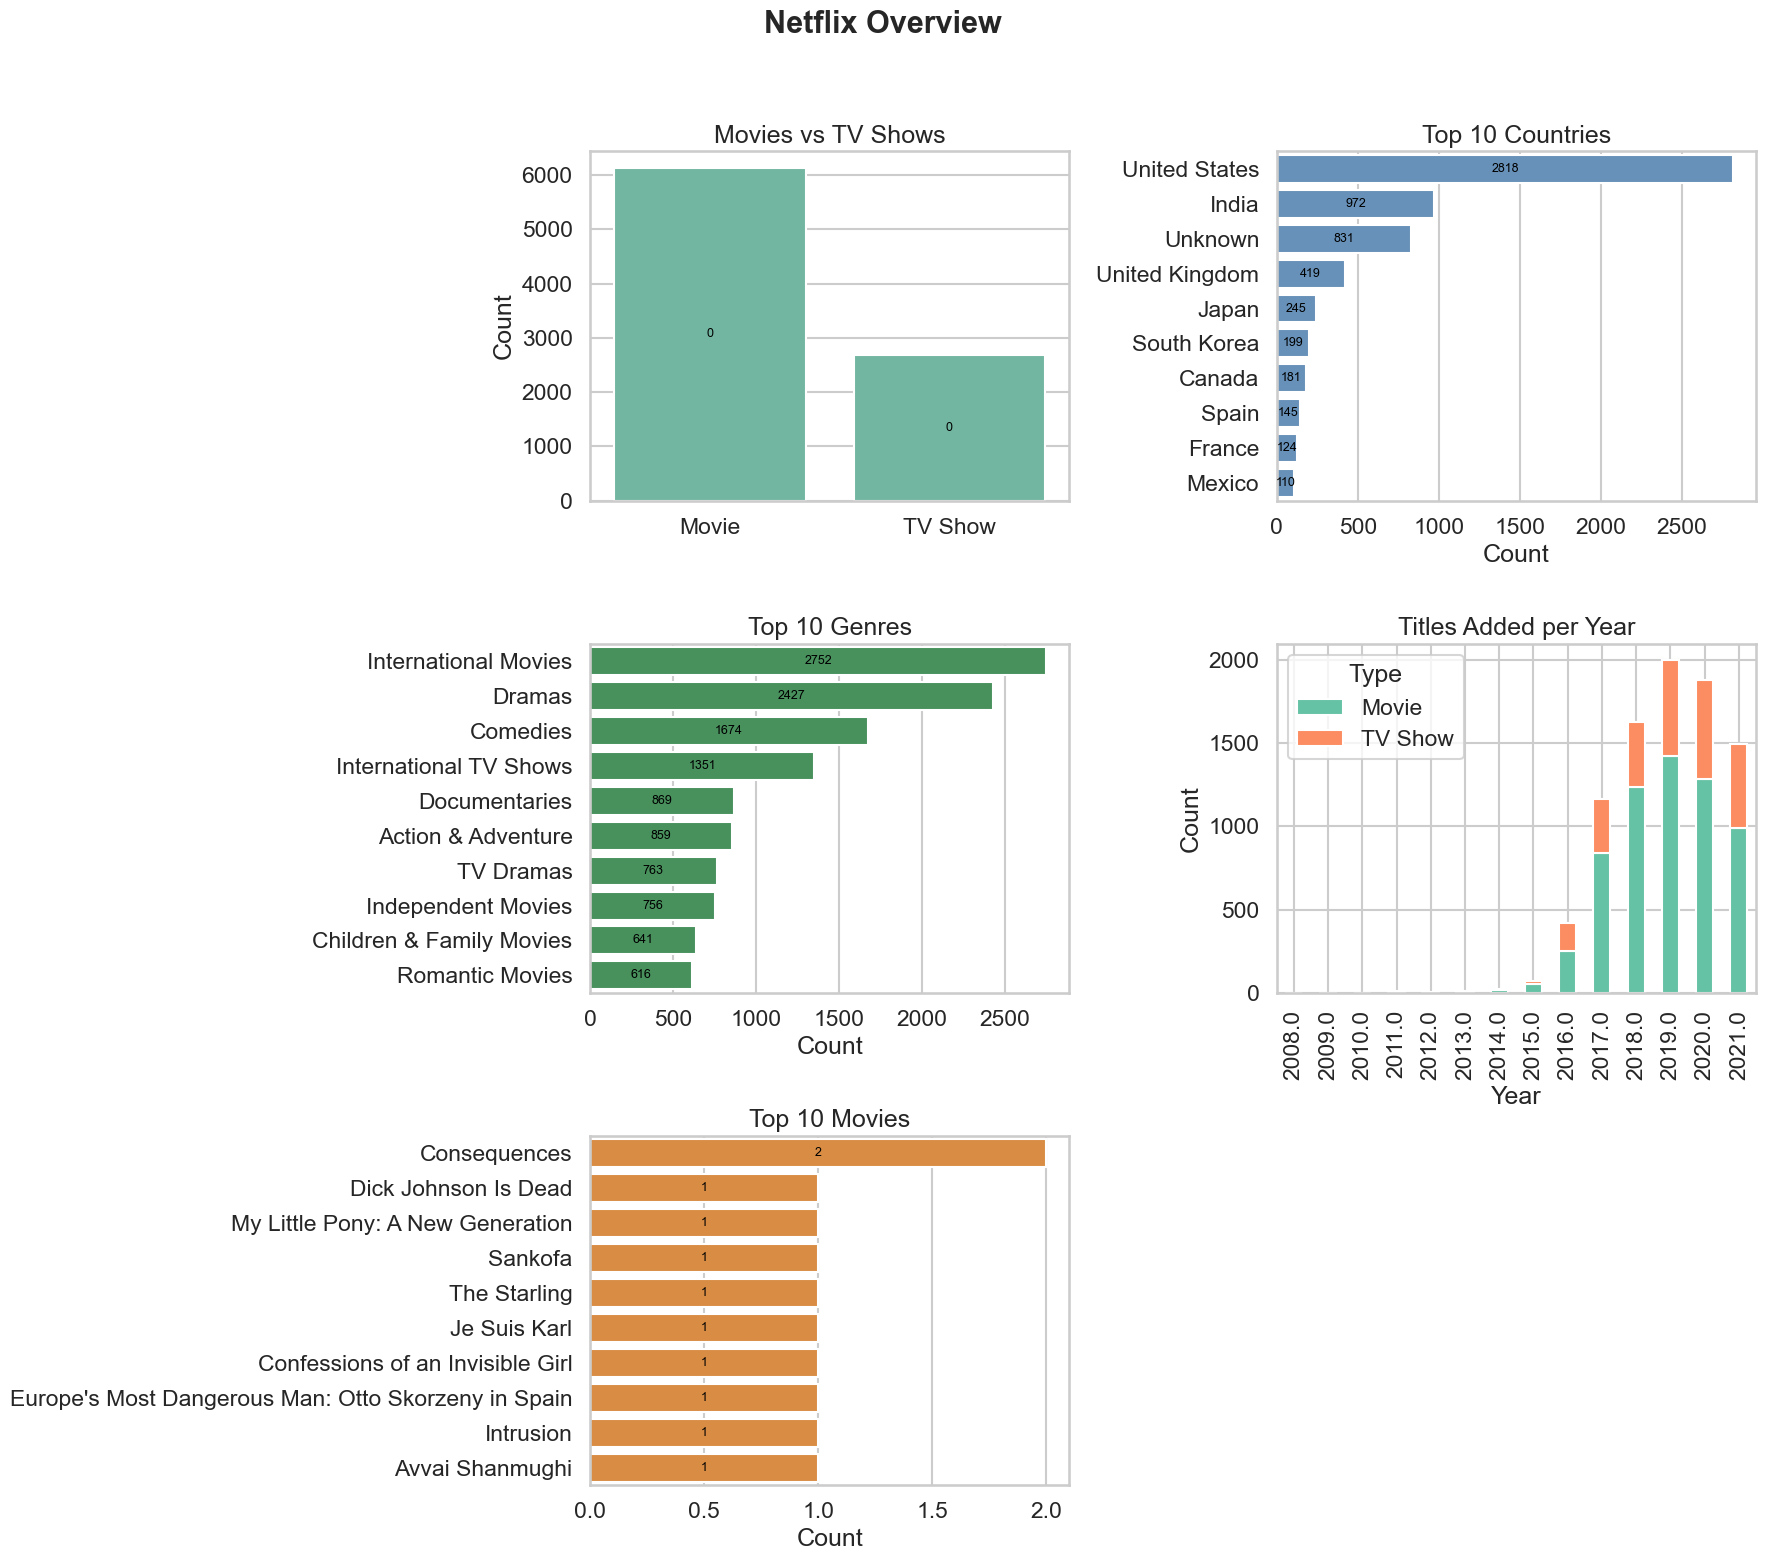

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

# load data
data_path = r'data/netflix_titles.csv'
df = pd.read_csv(data_path)

# fill missing info
df['country'].fillna('Unknown', inplace=True)
df['date_added'].fillna('Not Available', inplace=True)
for col in ['title', 'director', 'cast', 'country', 'listed_in', 'description']:
    df[col] = df[col].astype(str).str.strip()

# parse date
df['added_date'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['added_date'].dt.year

# helper to put numbers on bars
def label_bars(ax):
    for bar in ax.patches:
        val = bar.get_width() if hasattr(bar, 'get_width') else bar.get_height()
        if val > 0:
            ax.annotate(int(val),
                        (bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2),
                        ha='center', va='center', fontsize=9, color='black')

# prep top lists
top_countries = df['country'].value_counts().head(10)
all_genres = df['listed_in'].str.split(',').apply(lambda x: [g.strip() for g in x])
top_genres = pd.Series([g for sub in all_genres for g in sub]).value_counts().head(10)
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
movies = df[df['type']=='Movie']['title'].value_counts().head(10)

# set up canvas
fig, ax = plt.subplots(3,2, figsize=(18,16))
fig.suptitle('Netflix Overview', fontsize=22, weight='bold')

# movies vs shows
sns.countplot(data=df, x='type', color='#66c2a5', ax=ax[0,0])
ax[0,0].set_title('Movies vs TV Shows')
ax[0,0].set_ylabel('Count')
ax[0,0].set_xlabel('')
label_bars(ax[0,0])

# top countries
sns.barplot(x=top_countries.values, y=top_countries.index, color='#5a92c6', ax=ax[0,1])
ax[0,1].set_title('Top 10 Countries')
ax[0,1].set_xlabel('Count')
ax[0,1].set_ylabel('')
label_bars(ax[0,1])

# top genres
sns.barplot(x=top_genres.values, y=top_genres.index, color='#3c9d58', ax=ax[1,0])
ax[1,0].set_title('Top 10 Genres')
ax[1,0].set_xlabel('Count')
ax[1,0].set_ylabel('')
label_bars(ax[1,0])

# titles per year
yearly.plot(kind='bar', stacked=True, color=['#66c2a5','#fc8d62'], ax=ax[1,1])
ax[1,1].set_title('Titles Added per Year')
ax[1,1].set_xlabel('Year')
ax[1,1].set_ylabel('Count')
ax[1,1].legend(title='Type')

# top movies
sns.barplot(x=movies.values, y=movies.index, color='#f28c2b', ax=ax[2,0])
ax[2,0].set_title('Top 10 Movies')
ax[2,0].set_xlabel('Count')
ax[2,0].set_ylabel('')
label_bars(ax[2,0])

# empty subplot
ax[2,1].axis('off')

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('netflix_overview.jpg', dpi=300)
plt.show()